In [1]:
import pandas as pd
import numpy as np
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats import chi2_contingency, randint, uniform, ttest_ind
from scipy.stats.contingency import association

from sklearn import metrics
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OrdinalEncoder

# Input Dataset


In [2]:
df = pd.read_csv('Zara_sales_EDA.csv', sep=';')
df.head()

,Product ID,Product Position,Promotion,Product Category,Seasonal,Sales Volume,brand,url,name,description,price,currency,terms,section,season,material,origin
0,185102,Aisle,Yes,clothing,Yes,1243,Zara,https://www.zara.com/us/en/basic-puffer-jacket...,BASIC PUFFER JACKET,Puffer jacket made of tear-resistant ripstop f...,78.99,USD,jackets,MAN,Winter,Polyester,Brazil
1,188771,Aisle,Yes,clothing,No,1429,Zara,https://www.zara.com/us/en/tuxedo-jacket-p0889...,TUXEDO JACKET,Straight fit blazer. Pointed lapel collar and ...,14.99,USD,jackets,MAN,Autumn,Cotton,Turkey
2,180176,End-cap,Yes,clothing,Yes,1168,Zara,https://www.zara.com/us/en/slim-fit-suit-jacke...,SLIM FIT SUIT JACKET,Slim fit jacket. Notched lapel collar. Long sl...,71.95,USD,jackets,WOMAN,Autumn,Polyester,Morocco
3,112917,Aisle,Yes,clothing,No,1348,Zara,https://www.zara.com/us/en/stretch-suit-jacket...,STRETCH SUIT JACKET,Slim fit jacket made of viscose blend fabric. ...,30.99,USD,jackets,MAN,Spring,Polyester,China
4,192936,End-cap,Yes,clothing,Yes,1602,Zara,https://www.zara.com/us/en/double-faced-jacket...,DOUBLE FACED JACKET,Jacket made of faux leather faux shearling wit...,22.99,USD,jackets,WOMAN,Winter,Wool Blend,China


## Column Definiton

- Product ID : ID uniq for product
- Product position : where product position in store
- Promotion : are product being promotion or not
- Product Category : category for every product were there ini store
- Seasonal : are the product for seasonal or just there in every season
- Sales Volume : the amount of product who have been sold
- Brand : product brand just from Zara
- URL : link for the online store each product
- Name : name of the product
- Description : description of the product
- Price : price for each product include tax
- Currency : the type of money customer use
- Terms : Detail of the product
- Section : the sex of product can be use
- Season : the season of the product were sold
- Material : the material that use for the product
- Origin : The country where the product was manufactured or sourced

In [3]:
# merubah semua judul kolom menjadi huruf kecil dan spasi diganti dengan _
df.columns = df.columns.str.lower().str.replace(' ', '_')

In [4]:
df.head(5)

,product_id,product_position,promotion,product_category,seasonal,sales_volume,brand,url,name,description,price,currency,terms,section,season,material,origin
0,185102,Aisle,Yes,clothing,Yes,1243,Zara,https://www.zara.com/us/en/basic-puffer-jacket...,BASIC PUFFER JACKET,Puffer jacket made of tear-resistant ripstop f...,78.99,USD,jackets,MAN,Winter,Polyester,Brazil
1,188771,Aisle,Yes,clothing,No,1429,Zara,https://www.zara.com/us/en/tuxedo-jacket-p0889...,TUXEDO JACKET,Straight fit blazer. Pointed lapel collar and ...,14.99,USD,jackets,MAN,Autumn,Cotton,Turkey
2,180176,End-cap,Yes,clothing,Yes,1168,Zara,https://www.zara.com/us/en/slim-fit-suit-jacke...,SLIM FIT SUIT JACKET,Slim fit jacket. Notched lapel collar. Long sl...,71.95,USD,jackets,WOMAN,Autumn,Polyester,Morocco
3,112917,Aisle,Yes,clothing,No,1348,Zara,https://www.zara.com/us/en/stretch-suit-jacket...,STRETCH SUIT JACKET,Slim fit jacket made of viscose blend fabric. ...,30.99,USD,jackets,MAN,Spring,Polyester,China
4,192936,End-cap,Yes,clothing,Yes,1602,Zara,https://www.zara.com/us/en/double-faced-jacket...,DOUBLE FACED JACKET,Jacket made of faux leather faux shearling wit...,22.99,USD,jackets,WOMAN,Winter,Wool Blend,China


In [5]:
total_price = df['price'].sum()
print(total_price)

849552.3800000001


In [6]:
total_volume = df['sales_volume'].sum()
print(total_volume)

22224554


# Data Preparation

## Missing Value

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20252 entries, 0 to 20251
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   product_id        20252 non-null  int64  
 1   product_position  20252 non-null  object 
 2   promotion         20252 non-null  object 
 3   product_category  20252 non-null  object 
 4   seasonal          20252 non-null  object 
 5   sales_volume      20252 non-null  int64  
 6   brand             20252 non-null  object 
 7   url               20252 non-null  object 
 8   name              20251 non-null  object 
 9   description       20250 non-null  object 
 10  price             20252 non-null  float64
 11  currency          20252 non-null  object 
 12  terms             20252 non-null  object 
 13  section           20252 non-null  object 
 14  season            20252 non-null  object 
 15  material          20252 non-null  object 
 16  origin            20252 non-null  object

In [8]:
df.isnull().sum()

,0
product_id,0
product_position,0
promotion,0
product_category,0
seasonal,0
sales_volume,0
brand,0
url,0
name,1
description,2


because the missing value < 1% so the data will be drop

## Duplicate

In [9]:
df = df.dropna()

In [10]:
df.duplicated().sum()

np.int64(0)

there is no data were duplicated

## Outlier

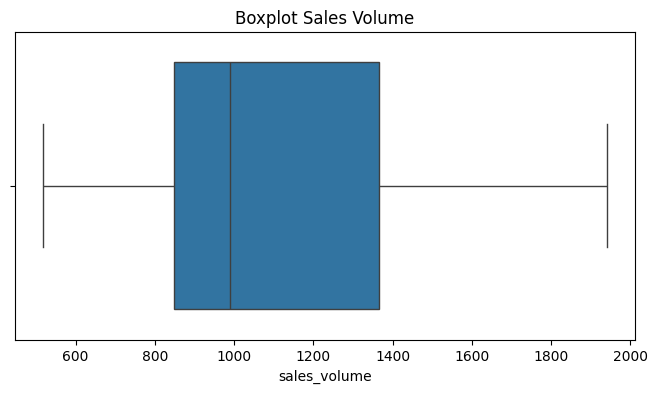

In [ ]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['sales_volume'])
plt.title("Boxplot Sales Volume")
plt.show()

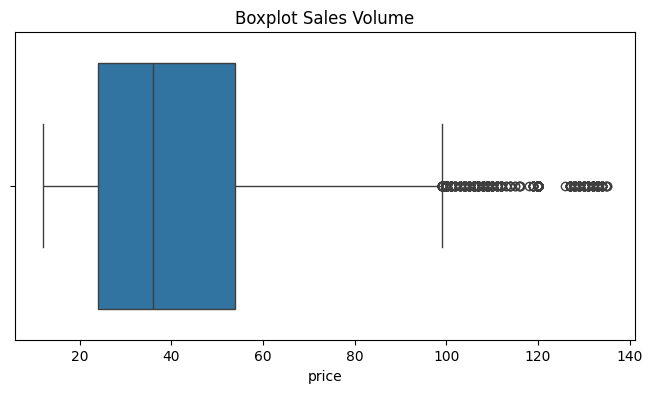

In [ ]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['price'])
plt.title("Boxplot Sales Volume")
plt.show()

In [ ]:
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['price'] < lower_bound) | (df['price'] > upper_bound)]

print("Jumlah outlier:", len(outliers))


Jumlah outlier: 641


In [ ]:
print("Persentase outlier:", len(outliers) / len(df) * 100, "%")

Persentase outlier: 3.165432098765432 %


there's outlier in column price, but price sometimes have the high value for some type of the product and product Zara is clothes

so we keep the outlier

## Data Type

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20250 entries, 0 to 20251
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   product_id        20250 non-null  int64  
 1   product_position  20250 non-null  object 
 2   promotion         20250 non-null  object 
 3   product_category  20250 non-null  object 
 4   seasonal          20250 non-null  object 
 5   sales_volume      20250 non-null  int64  
 6   brand             20250 non-null  object 
 7   url               20250 non-null  object 
 8   name              20250 non-null  object 
 9   description       20250 non-null  object 
 10  price             20250 non-null  float64
 11  currency          20250 non-null  object 
 12  terms             20250 non-null  object 
 13  section           20250 non-null  object 
 14  season            20250 non-null  object 
 15  material          20250 non-null  object 
 16  origin            20250 non-null  object 
dty

datatype already correct for all column, no need to change the datatype

# EDA

## Target & Fiture

In [ ]:
HEX_GREEN = '#9bbb59'
HEX_BLUE = '#48a8c4'
HEX_RED = '#c0504d'

In [ ]:
target_column = 'sales_volume'

# This variable does have an inherent order.
ordinal_columns = [
    'product_position'
]

# This variable doesn’t have an inherent order.
nominal_columns = [
    'promotion',
    'seasonal',
    'terms',
    'section',
    'season',
    'material',
    'origin'
]

category_columns = ordinal_columns + nominal_columns

numeric_columns = [
    'price'
]

## Categorical

/tmp/ipython-input-3694574770.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(
/tmp/ipython-input-3694574770.py:18: UserWarning: The palette list has more values (10) than needed (3), which may not be intended.
  ax = sns.barplot(


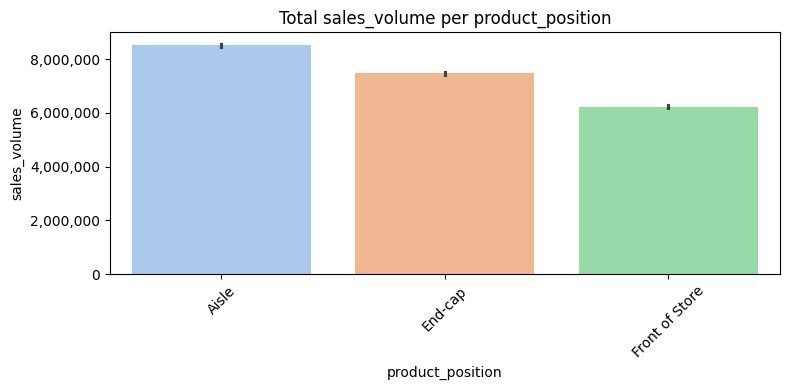

/tmp/ipython-input-3694574770.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(
/tmp/ipython-input-3694574770.py:18: UserWarning: The palette list has more values (10) than needed (2), which may not be intended.
  ax = sns.barplot(


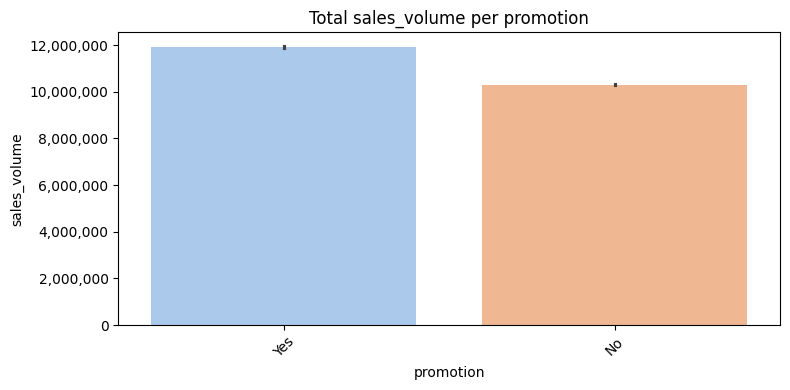

/tmp/ipython-input-3694574770.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(
/tmp/ipython-input-3694574770.py:18: UserWarning: The palette list has more values (10) than needed (2), which may not be intended.
  ax = sns.barplot(


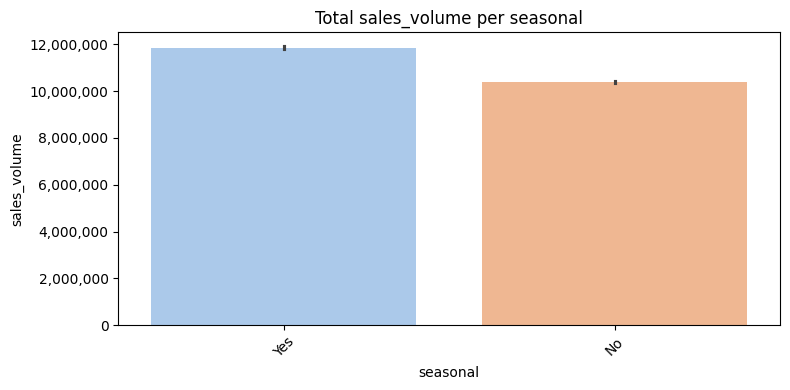

/tmp/ipython-input-3694574770.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(
/tmp/ipython-input-3694574770.py:18: UserWarning: The palette list has more values (10) than needed (5), which may not be intended.
  ax = sns.barplot(


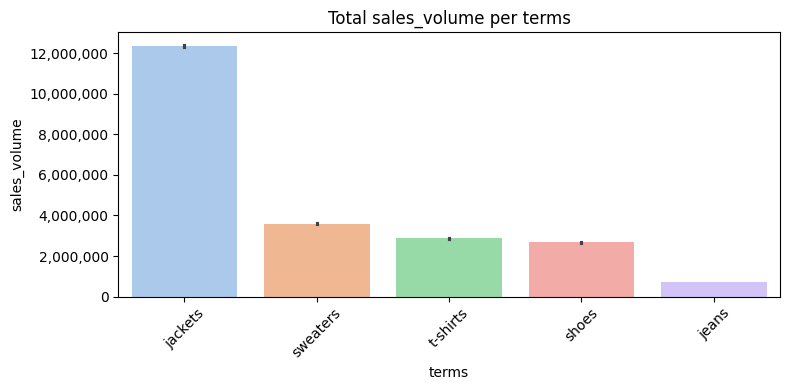

/tmp/ipython-input-3694574770.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(
/tmp/ipython-input-3694574770.py:18: UserWarning: The palette list has more values (10) than needed (2), which may not be intended.
  ax = sns.barplot(


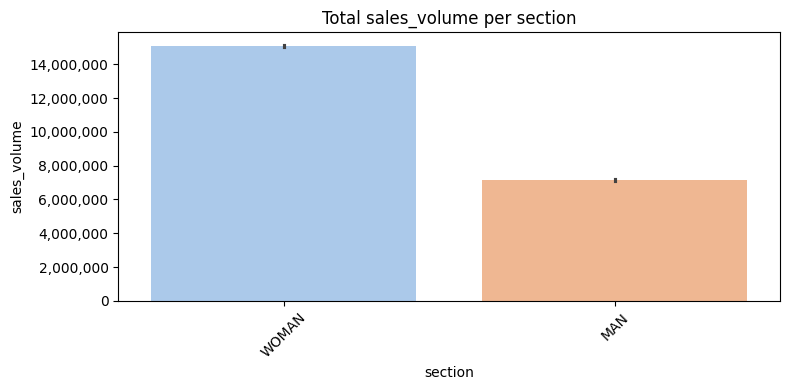

/tmp/ipython-input-3694574770.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(
/tmp/ipython-input-3694574770.py:18: UserWarning: The palette list has more values (10) than needed (4), which may not be intended.
  ax = sns.barplot(


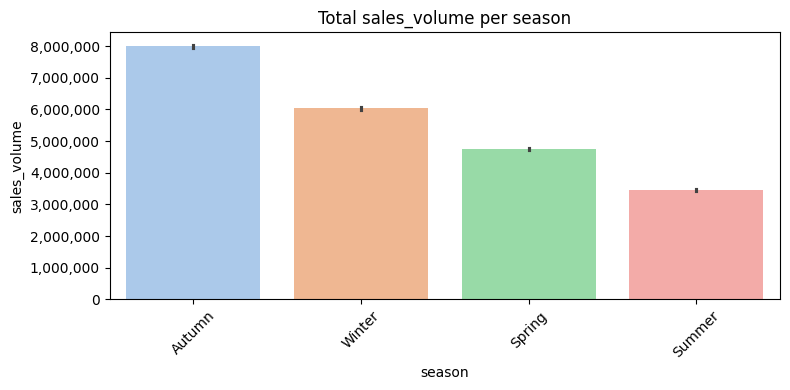

/tmp/ipython-input-3694574770.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(
/tmp/ipython-input-3694574770.py:18: UserWarning: 
The palette list has fewer values (10) than needed (11) and will cycle, which may produce an uninterpretable plot.
  ax = sns.barplot(


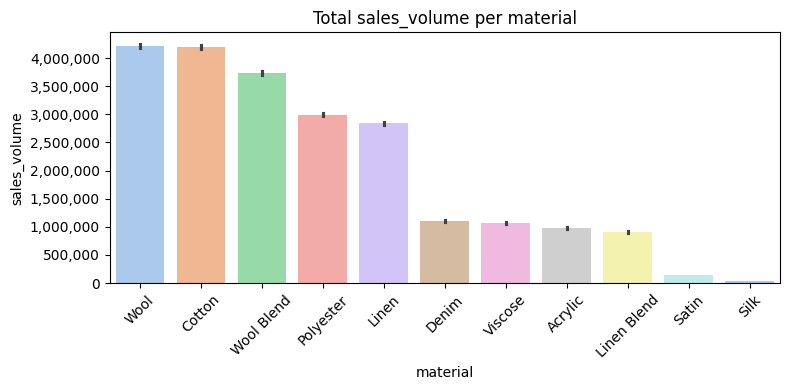

/tmp/ipython-input-3694574770.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(
/tmp/ipython-input-3694574770.py:18: UserWarning: 
The palette list has fewer values (10) than needed (12) and will cycle, which may produce an uninterpretable plot.
  ax = sns.barplot(


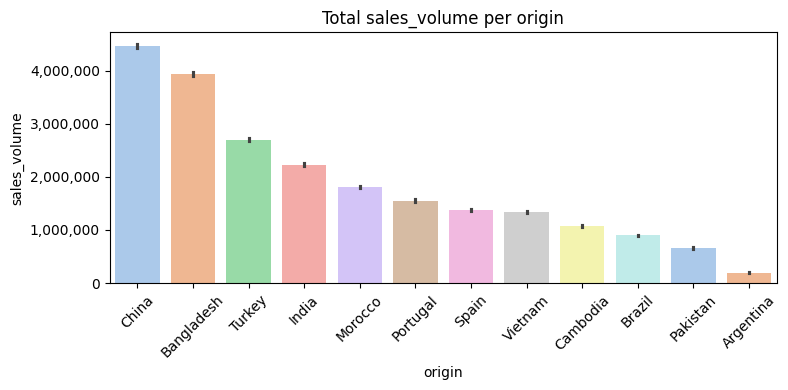

In [ ]:
import matplotlib.ticker as mtick
import matplotlib.pyplot as plt
import seaborn as sns

palette = sns.color_palette("pastel")

for col in category_columns:

    # hitung total sales per kategori lalu sort
    order = (
        df.groupby(col)['sales_volume']
        .sum()
        .sort_values(ascending=False)   # ubah ke True jika mau dari kecil ke besar
        .index
    )

    plt.figure(figsize=(8,4))
    ax = sns.barplot(
        data=df,
        x=col,
        y='sales_volume',
        palette=palette,
        estimator=sum,
        order=order                    # <--- tambahkan order
    )

    plt.title(f'Total sales_volume per {col}')
    plt.xticks(rotation=45)

    ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))

    plt.tight_layout()
    plt.show()


## Numeric

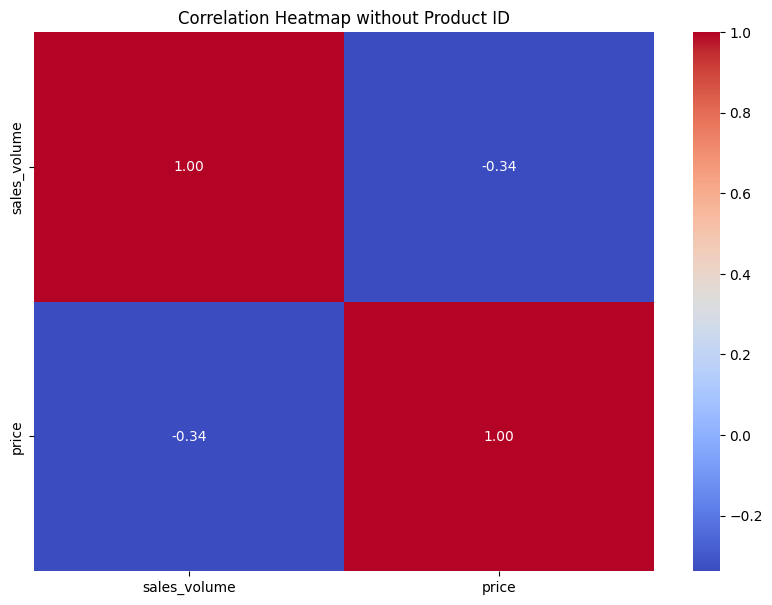

In [ ]:
df_corr = df.drop(columns=['product_id'])

corr = df_corr.corr(numeric_only=True)

plt.figure(figsize=(10,7))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap without Product ID")
plt.show()

# Split Data

Optimal Split Data is 80% train and 20% test

In [ ]:
X = df.drop(columns=[target_column, 'product_id', 'product_category', 'brand', 'url', 'name', 'description', 'currency'])
y = df[[target_column]]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

## Variable Feature

In [ ]:
X_train.shape

(16200, 9)

In [ ]:
X_test.shape

(4050, 9)

## Variable Target

In [ ]:
y_train.shape

(16200, 1)

In [ ]:
y_test.shape

(4050, 1)

7 fiture column already drop so it's just 9 feature we use to modelling

## Encode Ordinal Variable

In [ ]:
encoder = OrdinalEncoder(
    categories=[['End-cap', 'Aisle', 'Front of Store']],
    handle_unknown='error',
)

X_train['product_position'] = encoder.fit_transform(X_train[['product_position']])
X_test['product_position'] = encoder.transform(X_test[['product_position']])

## Encode Nominal Variable

In [ ]:
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

# Buat encoder
ohe = OneHotEncoder(sparse_output=False, drop='first')  # drop='first' untuk linear model

for col in nominal_columns:
    # Fit di train
    ohe_fit = ohe.fit(X_train[[col]])
    transformed_train = ohe_fit.transform(X_train[[col]])
    transformed_test = ohe_fit.transform(X_test[[col]])

    # Buat nama kolom baru
    new_cols = [f"{col}_{cat}" for cat in ohe_fit.categories_[0][1:]]  # karena drop first

    # Masukkan ke dataframe
    X_train[new_cols] = pd.DataFrame(transformed_train, index=X_train.index)
    X_test[new_cols] = pd.DataFrame(transformed_test, index=X_test.index)

    # Hapus kolom lama
    X_train.drop(columns=col, inplace=True)
    X_test.drop(columns=col, inplace=True)


In [ ]:
X_train.head()

,product_position,price,promotion_Yes,seasonal_Yes,terms_jeans,terms_shoes,terms_sweaters,terms_t-shirts,section_WOMAN,season_Spring,...,origin_Brazil,origin_Cambodia,origin_China,origin_India,origin_Morocco,origin_Pakistan,origin_Portugal,origin_Spain,origin_Turkey,origin_Vietnam
10415,0.0,99.99,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
7461,0.0,24.95,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
18806,1.0,33.99,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
18351,2.0,39.95,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10680,0.0,89.99,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Scale Numeric Variable

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_train['price'] = scaler.fit_transform(X_train[['price']])
X_test['price'] = scaler.transform(X_test[['price']])

scaler.inverse_transform([[1]])

array([[134.99]])

In [ ]:
X_train[numeric_columns].sample(5)

,price
12984,0.170664
18520,0.064639
3575,0.113749
10155,0.064965
4269,0.170339


# VIF

In [ ]:
# calculate VIF scores
from statsmodels.stats.outliers_influence import variance_inflation_factor as vif
from statsmodels.tools.tools import add_constant

X = add_constant(X_train)

vif_df = pd.DataFrame([vif(X.values, i)
               for i in range(X.shape[1])],
              index=X.columns).reset_index()
vif_df.columns = ['feature','vif_score']
vif_df = vif_df.loc[vif_df.feature!='const']
vif_df

,feature,vif_score
1,product_position,1.001767
2,price,1.028728
3,promotion_Yes,1.101937
4,seasonal_Yes,1.082706
5,terms_jeans,1.026379
6,terms_shoes,1.073209
7,terms_sweaters,1.085728
8,terms_t-shirts,1.077595
9,section_WOMAN,1.002088
10,season_Spring,1.924073


/tmp/ipython-input-3767404858.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=vif_df_sorted, x='vif_score', y='feature', palette='pastel')


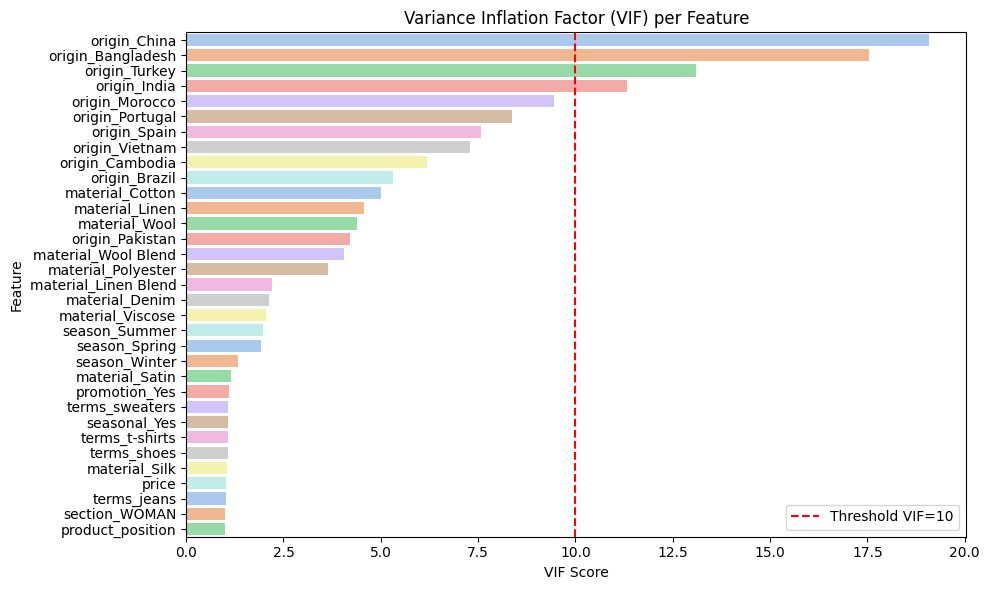

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Sort nilai VIF descending supaya mudah dibaca
vif_df_sorted = vif_df.sort_values('vif_score', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(data=vif_df_sorted, x='vif_score', y='feature', palette='pastel')
plt.axvline(10, color='red', linestyle='--', label='Threshold VIF=10')
plt.title('Variance Inflation Factor (VIF) per Feature')
plt.xlabel('VIF Score')
plt.ylabel('Feature')
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
# drop redundant features
X_train = X_train.drop(columns=['origin_Turkey'])
X_test = X_test.drop(columns=['origin_Turkey'])

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor as vif
from statsmodels.tools.tools import add_constant

X = add_constant(X_train)

vif_df = pd.DataFrame([vif(X.values, i)
               for i in range(X.shape[1])],
              index=X.columns).reset_index()
vif_df.columns = ['feature','vif_score']
vif_df = vif_df.loc[vif_df.feature!='const']
vif_df

,feature,vif_score
1,product_position,1.001766
2,price,1.028601
3,promotion_Yes,1.101936
4,seasonal_Yes,1.082678
5,terms_jeans,1.026293
6,terms_shoes,1.073151
7,terms_sweaters,1.085712
8,terms_t-shirts,1.077593
9,section_WOMAN,1.002084
10,season_Spring,1.924067


/tmp/ipython-input-3767404858.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=vif_df_sorted, x='vif_score', y='feature', palette='pastel')


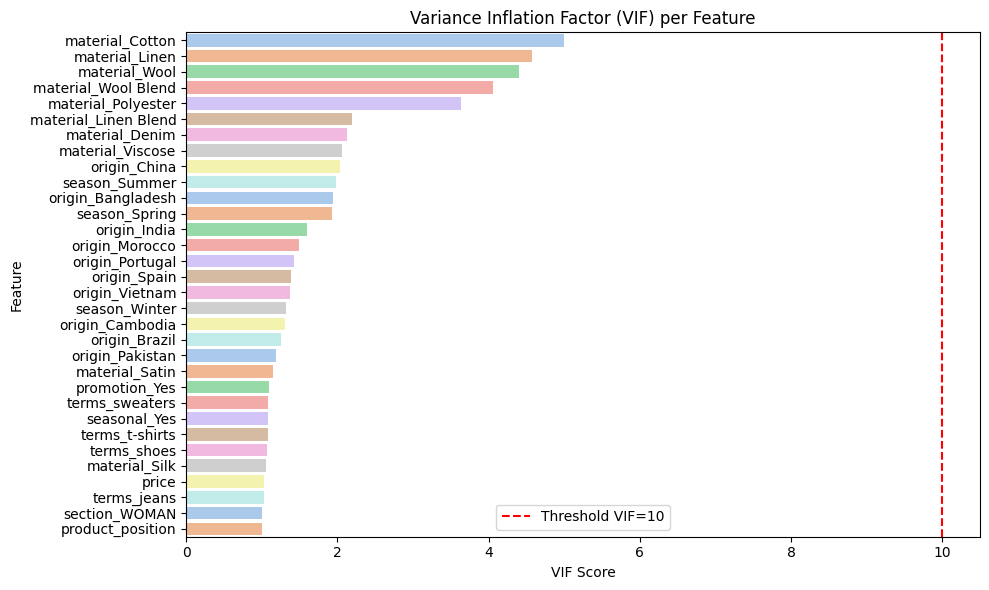

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Sort nilai VIF descending supaya mudah dibaca
vif_df_sorted = vif_df.sort_values('vif_score', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(data=vif_df_sorted, x='vif_score', y='feature', palette='pastel')
plt.axvline(10, color='red', linestyle='--', label='Threshold VIF=10')
plt.title('Variance Inflation Factor (VIF) per Feature')
plt.xlabel('VIF Score')
plt.ylabel('Feature')
plt.legend()
plt.tight_layout()
plt.show()


# Modeling

## Linear Regression

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression().fit(X_train, y_train)

In [ ]:
y_pred_train_lr = model.predict(X_train)
y_pred_test_lr = model.predict(X_test)

In [ ]:
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error,
    mean_absolute_percentage_error
)
import numpy as np

# R-squared
r2_train = r2_score(y_train, y_pred_train_lr)
r2_test = r2_score(y_test, y_pred_test_lr)

# RMSE
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train_lr))
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test_lr))

# MAE
mae_train = mean_absolute_error(y_train, y_pred_train_lr)
mae_test = mean_absolute_error(y_test, y_pred_test_lr)

# MAPE
mape_train = mean_absolute_percentage_error(y_train, y_pred_train_lr) * 100
mape_test = mean_absolute_percentage_error(y_test, y_pred_test_lr) * 100

print(f"Training R2: {r2_train*100:.2f}%")
print(f"Testing R2: {r2_test*100:.2f}%")
print(f"Training RMSE: {rmse_train:.2f}")
print(f"Testing RMSE: {rmse_test:.2f}")
print(f"Training MAE: {mae_train:.2f}")
print(f"Testing MAE: {mae_test:.2f}")
print(f"Training MAPE: {mape_train:.2f}%")
print(f"Testing MAPE: {mape_test:.2f}%")


Training R2: 93.03%
Testing R2: 92.92%
Training RMSE: 79.21
Testing RMSE: 77.33
Training MAE: 62.47
Testing MAE: 61.45
Training MAPE: 5.80%
Testing MAPE: 5.73%


## Ridge

### Default Parameter

In [ ]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler

model_ridge = Ridge(
    alpha=1.0,             # kekuatan regularisasi L2
    fit_intercept=True,    # apakah model menambahkan intercept
    copy_X=True,
    max_iter=None,
    tol=1e-3,
    solver='auto',
    random_state=None
)

model_ridge.fit(X_train, y_train)

scores_ridge = cross_val_score(
    model_ridge,
    X_train,
    y_train,
    cv=5,
    scoring='r2'  # scoring bisa diganti 'neg_mean_absolute_error' juga
)


R2 Mean : 0.93
R2 STD : 0.002


<Axes: >

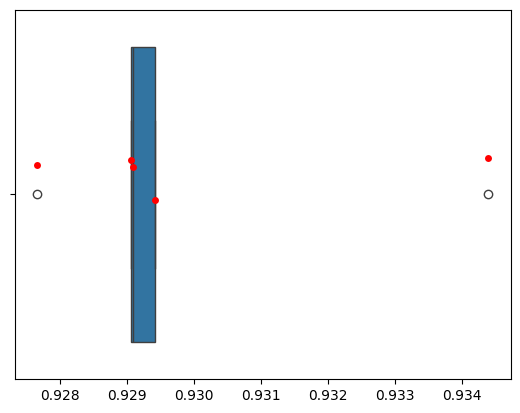

In [ ]:
print('R2 Mean :', round(scores_ridge.mean(), 3))
print('R2 STD :', round(scores_ridge.std(), 3))

sns.boxplot(x=scores_ridge, orient='h')
sns.stripplot(x=scores_ridge, color='red')

In [ ]:
y_train_pred_ridge = model_ridge.predict(X_train)
y_test_pred_ridge = model_ridge.predict(X_test)

### R2, RMSE, MAE

In [ ]:
from sklearn.metrics import mean_absolute_percentage_error

print('Train MAE:', round(mean_absolute_error(y_train, y_train_pred_ridge), 3))
print('Train RMSE:', round(np.sqrt(mean_squared_error(y_train, y_train_pred_ridge)), 3))
print('Train R2:', round(r2_score(y_train, y_train_pred_ridge)* 100, 3), '%')
print('Train MAPE:', round(mean_absolute_percentage_error(y_train, y_train_pred_ridge) * 100, 3), '%')

print('Test MAE:', round(mean_absolute_error(y_test, y_test_pred_ridge), 3))
print('Test RMSE:', round(np.sqrt(mean_squared_error(y_test, y_test_pred_ridge)), 3))
print('Test R2:', round(r2_score(y_test, y_test_pred_ridge)* 100, 3), '%')
print('Test MAPE:', round(mean_absolute_percentage_error(y_test, y_test_pred_ridge) * 100, 3), '%')

Train MAE: 62.459
Train RMSE: 79.211
Train R2: 93.031 %
Train MAPE: 5.8 %
Test MAE: 61.441
Test RMSE: 77.33
Test R2: 92.918 %
Test MAPE: 5.729 %


In [ ]:
coef_df = pd.DataFrame({
    'feature':['intercept'] + X_train.columns.tolist(),
    'coefficient':[model_ridge.intercept_] + list(model_ridge.coef_)
})

coef_df

,feature,coefficient
0,intercept,[841.854129208881]
1,product_position,0.074869
2,price,-365.578555
3,promotion_Yes,520.972281
4,seasonal_Yes,1.428689
5,terms_jeans,1.644332
6,terms_shoes,-0.469738
7,terms_sweaters,-1.576368
8,terms_t-shirts,-2.925376
9,section_WOMAN,106.366189


### Hyperparameter tuning

In [ ]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import RandomizedSearchCV, cross_val_score, train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
parameters_ridge = {
    'alpha': np.logspace(-4, 4, 50),
    'solver': ['auto', 'svd', 'cholesky', 'lsqr', 'saga'],
    'fit_intercept': [True, False],
    'tol': [1e-4, 1e-3, 1e-2]
}

ridge = Ridge()

ridge_grid = RandomizedSearchCV(
    estimator=ridge,
    param_distributions=parameters_ridge,
    n_iter=20,
    cv=5,
    scoring='r2',
    verbose=True,
    n_jobs=-1,
    random_state=42
)

ridge_grid.fit(X_train, y_train)

print("Best parameters:", ridge_grid.best_params_)
print("Best R2 score:", ridge_grid.best_score_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters: {'tol': 0.001, 'solver': 'cholesky', 'fit_intercept': True, 'alpha': np.float64(0.18420699693267145)}
Best R2 score: 0.9299213186587199


### Best Parameter

In [ ]:
best_params = ridge_grid.best_params_

model_ridge_hy = Ridge(
    alpha=best_params['alpha'],
    solver=best_params['solver'],
    fit_intercept=best_params['fit_intercept'],
    tol=best_params['tol']
)

model_ridge_hy.fit(X_train, y_train)

Ridge(alpha=np.float64(0.18420699693267145), solver='cholesky', tol=0.001)

R2 Mean (CV) : 0.93
R2 STD (CV) : 0.002


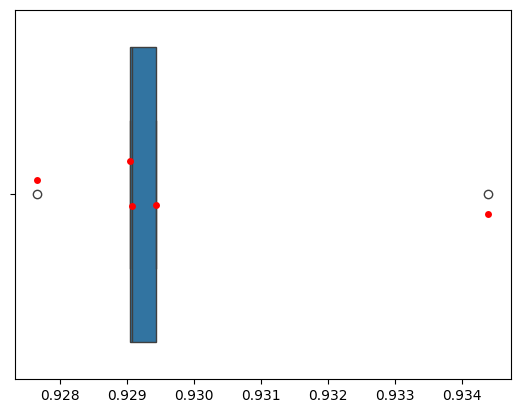

In [ ]:
scores_ridge_hy = cross_val_score(
    model_ridge_hy,
    X_train,
    y_train,
    cv=5,
    scoring='r2'
)

print('R2 Mean (CV) :', round(scores_ridge_hy.mean(), 3))
print('R2 STD (CV) :', round(scores_ridge_hy.std(), 3))

sns.boxplot(x=scores_ridge_hy, orient='h')
sns.stripplot(x=scores_ridge_hy, color='red')
plt.show()


In [ ]:
y_train_pred_rhy = model_ridge_hy.predict(X_train)
y_test_pred_rhy = model_ridge_hy.predict(X_test)

In [ ]:
print('Train MAE:', round(mean_absolute_error(y_train, y_train_pred_rhy), 3))
print('Train RMSE:', round(np.sqrt(mean_squared_error(y_train, y_train_pred_rhy)), 3))
print('Train R2:', round(r2_score(y_train, y_train_pred_rhy)* 100, 3), '%')
print('Train MAPE:', round(mean_absolute_percentage_error(y_train, y_train_pred_rhy) * 100, 3), '%')

print('Test MAE:', round(mean_absolute_error(y_test, y_test_pred_rhy), 3))
print('Test RMSE:', round(np.sqrt(mean_squared_error(y_test, y_test_pred_rhy)), 3))
print('Test R2:', round(r2_score(y_test, y_test_pred_rhy)* 100, 3), '%')
print('Test MAPE:', round(mean_absolute_percentage_error(y_test, y_test_pred_rhy) * 100, 3), '%')

Train MAE: 62.465
Train RMSE: 79.211
Train R2: 93.031 %
Train MAPE: 5.801 %
Test MAE: 61.446
Test RMSE: 77.33
Test R2: 92.918 %
Test MAPE: 5.73 %


## Lasso

### Default Parameter

In [ ]:
from sklearn.linear_model import Lasso

model_lasso = Lasso(
    alpha=0.1,           # kekuatan regularisasi L1 (biasanya lebih kecil dari Ridge)
    fit_intercept=True,   # apakah model menambahkan intercept
    max_iter=10000,       # pastikan konvergen
    tol=1e-4,             # toleransi konvergensi
    random_state=None
)

model_lasso.fit(X_train, y_train)

scores_lasso = cross_val_score(
    model_lasso,
    X_train,
    y_train,
    cv=5,
    scoring='r2'  # scoring bisa diganti 'neg_mean_absolute_error' juga
)


In [ ]:
print('CV R2 Mean :', round(scores_lasso.mean(), 3))
print('CV R2 STD :', round(scores_lasso.std(), 3))

CV R2 Mean : 0.93
CV R2 STD : 0.002


R2 Mean : 0.93
R2 STD : 0.002


<Axes: >

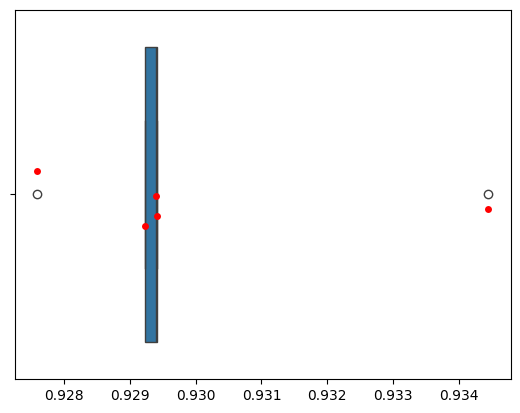

In [ ]:
print('R2 Mean :', round(scores_lasso.mean(), 3))
print('R2 STD :', round(scores_lasso.std(), 3))

sns.boxplot(x=scores_lasso, orient='h')
sns.stripplot(x=scores_lasso, color='red')

In [ ]:
y_train_pred_lasso = model_lasso.predict(X_train)
y_test_pred_lasso = model_lasso.predict(X_test)

### R2, RMSE, MAE

In [ ]:
print('Train MAE:', round(mean_absolute_error(y_train, y_train_pred_lasso), 3))
print('Train RMSE:', round(np.sqrt(mean_squared_error(y_train, y_train_pred_lasso)), 3))
print('Train R2:', round(r2_score(y_train, y_train_pred_lasso)* 100, 3), '%')
print('Train MAPE:', round(mean_absolute_percentage_error(y_train, y_train_pred_lasso) * 100, 3), '%')

print('Test MAE:', round(mean_absolute_error(y_test, y_test_pred_lasso), 3))
print('Test RMSE:', round(np.sqrt(mean_squared_error(y_test, y_test_pred_lasso)), 3))
print('Test R2:', round(r2_score(y_test, y_test_pred_lasso)* 100, 3), '%')
print('Test MAPE:', round(mean_absolute_percentage_error(y_test, y_test_pred_lasso) * 100, 3), '%')

Train MAE: 62.462
Train RMSE: 79.245
Train R2: 93.025 %
Train MAPE: 5.796 %
Test MAE: 61.393
Test RMSE: 77.331
Test R2: 92.918 %
Test MAPE: 5.72 %


### Hyperapameter Tuning

In [ ]:
parameters_lasso = {
    'alpha': np.logspace(-4, 1, 50),   # kekuatan regularisasi L1
    'fit_intercept': [True, False],
    'tol': [1e-4, 1e-3, 1e-2],
    'max_iter': [1000, 5000, 10000]    # pastikan konvergen
}

lasso = Lasso()

lasso_grid = RandomizedSearchCV(
    estimator=lasso,
    param_distributions=parameters_lasso,
    n_iter=20,
    cv=5,
    scoring='r2',
    verbose=True,
    n_jobs=-1,
    random_state=42
)

lasso_grid.fit(X_train, y_train)

print("Best parameters:", lasso_grid.best_params_)
print("Best R2 score:", lasso_grid.best_score_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters: {'tol': 0.01, 'max_iter': 10000, 'fit_intercept': True, 'alpha': np.float64(0.022229964825261957)}
Best R2 score: 0.9299541942955211


### Best Parameter

In [ ]:
best_params = lasso_grid.best_params_

model_lasso_hy = Lasso(
    alpha=best_params['alpha'],
    fit_intercept=best_params['fit_intercept'],
    tol=best_params['tol'],
    max_iter=best_params['max_iter']
)

model_lasso_hy.fit(X_train, y_train)

Lasso(alpha=np.float64(0.022229964825261957), max_iter=10000, tol=0.01)

R2 Mean (CV) : 0.93
R2 STD (CV) : 0.002


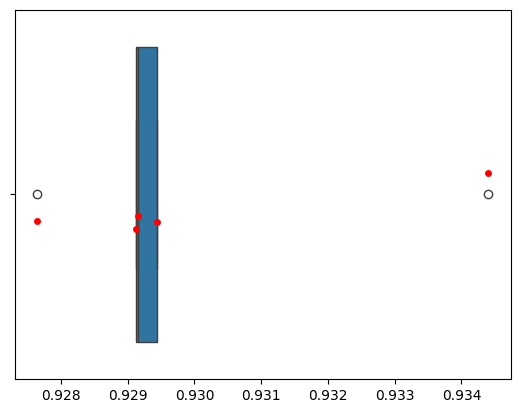

In [ ]:
scores_lasso_hy = cross_val_score(
    model_lasso_hy,
    X_train,
    y_train,
    cv=5,
    scoring='r2'
)

print('R2 Mean (CV) :', round(scores_lasso_hy.mean(), 3))
print('R2 STD (CV) :', round(scores_lasso_hy.std(), 3))

sns.boxplot(x=scores_lasso_hy, orient='h')
sns.stripplot(x=scores_lasso_hy, color='red')
plt.show()

In [ ]:
y_train_pred_lhy = model_lasso_hy.predict(X_train)
y_test_pred_lhy = model_lasso_hy.predict(X_test)

In [ ]:
print('Train MAE:', round(mean_absolute_error(y_train, y_train_pred_lhy), 3))
print('Train RMSE:', round(np.sqrt(mean_squared_error(y_train, y_train_pred_lhy)), 3))
print('Train R2:', round(r2_score(y_train, y_train_pred_lhy)* 100, 3), '%')
print('Train MAPE:', round(mean_absolute_percentage_error(y_train, y_train_pred_lhy) * 100, 3), '%')

print('Test MAE:', round(mean_absolute_error(y_test, y_test_pred_lhy), 3))
print('Test RMSE:', round(np.sqrt(mean_squared_error(y_test, y_test_pred_lhy)), 3))
print('Test R2:', round(r2_score(y_test, y_test_pred_lhy)* 100, 3), '%')
print('Test MAPE:', round(mean_absolute_percentage_error(y_test, y_test_pred_lhy) * 100, 3), '%')

Train MAE: 62.464
Train RMSE: 79.214
Train R2: 93.031 %
Train MAPE: 5.8 %
Test MAE: 61.439
Test RMSE: 77.336
Test R2: 92.917 %
Test MAPE: 5.728 %


## Decision Tree

### Default Parameter

In [ ]:
from sklearn.tree import DecisionTreeRegressor

# Inisialisasi model Decision Tree
model_tree = DecisionTreeRegressor(
    max_depth=5,       # batasi kedalaman tree
    random_state=42
)

# Fit model ke training set
model_tree.fit(X_train, y_train)

scores_tree = cross_val_score(
    model_tree,
    X_train,
    y_train,
    cv=5,
    scoring='r2'
)

In [ ]:
print('CV R2 Mean :', round(scores_tree.mean(), 3))
print('CV R2 STD :', round(scores_tree.std(), 3))

CV R2 Mean : 0.926
CV R2 STD : 0.002


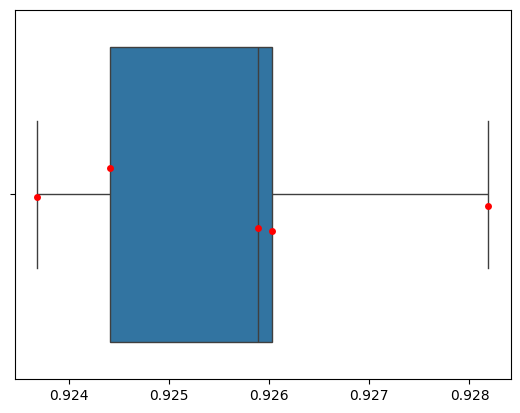

In [ ]:
sns.boxplot(x=scores_tree, orient='h')
sns.stripplot(x=scores_tree, color='red')
plt.show()

In [ ]:
y_train_pred_tree = model_tree.predict(X_train)
y_test_pred_tree = model_tree.predict(X_test)

### R2, RMSE, MAE

In [ ]:
print('Train MAE:', round(mean_absolute_error(y_train, y_train_pred_tree), 3))
print('Train RMSE:', round(np.sqrt(mean_squared_error(y_train, y_train_pred_tree)), 3))
print('Train R2:', round(r2_score(y_train, y_train_pred_tree)* 100, 3), '%')
print('Train MAPE:', round(mean_absolute_percentage_error(y_train, y_train_pred_tree) * 100, 3), '%')

print('Test MAE:', round(mean_absolute_error(y_test, y_test_pred_tree), 3))
print('Test RMSE:', round(np.sqrt(mean_squared_error(y_test, y_test_pred_tree)), 3))
print('Test R2:', round(r2_score(y_test, y_test_pred_tree)* 100, 3), '%')
print('Test MAPE:', round(mean_absolute_percentage_error(y_test, y_test_pred_tree) * 100, 3), '%')

Train MAE: 64.077
Train RMSE: 81.223
Train R2: 92.673 %
Train MAPE: 5.957 %
Test MAE: 64.071
Test RMSE: 80.913
Test R2: 92.247 %
Test MAPE: 5.989 %


### Hyperapameter Tuning

In [ ]:
parameters_tree = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

dt_model = DecisionTreeRegressor(random_state=42)

dt_grid = RandomizedSearchCV(
    estimator=dt_model,
    param_distributions=parameters_tree,
    n_iter=20,
    cv=5,
    scoring='r2',
    verbose=True,
    n_jobs=-1,
    random_state=42
)

dt_grid.fit(X_train, y_train)

print("Best parameters:", dt_grid.best_params_)
print("Best R2 score (CV):", dt_grid.best_score_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters: {'min_samples_split': 10, 'min_samples_leaf': 4, 'max_depth': 7}
Best R2 score (CV): 0.9348985521712709


### Best Parameter

In [ ]:
best_params = dt_grid.best_params_

dt_model_hy = DecisionTreeRegressor(
    max_depth=best_params['max_depth'],
    min_samples_split=best_params['min_samples_split'],
    min_samples_leaf=best_params['min_samples_leaf'],
    random_state=42
)

dt_model_hy.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=7, min_samples_leaf=4, min_samples_split=10,
                      random_state=42)

R2 Mean (CV) : 0.935
R2 STD (CV) : 0.002


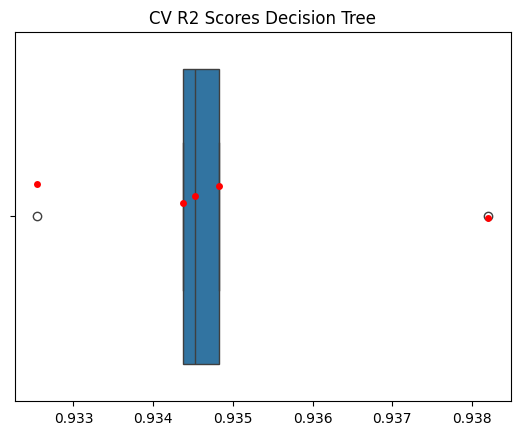

In [ ]:
scores_tree_hy = cross_val_score(
    dt_model_hy,
    X_train,
    y_train,
    cv=5,
    scoring='r2'
)

print('R2 Mean (CV) :', round(scores_tree_hy.mean(), 3))
print('R2 STD (CV) :', round(scores_tree_hy.std(), 3))

sns.boxplot(x=scores_tree_hy, orient='h')
sns.stripplot(x=scores_tree_hy, color='red')
plt.title("CV R2 Scores Decision Tree")
plt.show()



In [ ]:
y_train_pred_dt = dt_model_hy.predict(X_train)
y_test_pred_dt = dt_model_hy.predict(X_test)

In [ ]:
print('Train MAE:', round(mean_absolute_error(y_train, y_train_pred_dt), 3))
print('Train RMSE:', round(np.sqrt(mean_squared_error(y_train, y_train_pred_dt)), 3))
print('Train R2:', round(r2_score(y_train, y_train_pred_dt)* 100, 3), '%')
print('Train MAPE:', round(mean_absolute_percentage_error(y_train, y_train_pred_dt) * 100, 3), '%')

print('Test MAE:', round(mean_absolute_error(y_test, y_test_pred_dt), 3))
print('Test RMSE:', round(np.sqrt(mean_squared_error(y_test, y_test_pred_dt)), 3))
print('Test R2:', round(r2_score(y_test, y_test_pred_dt)* 100, 3), '%')
print('Test MAPE:', round(mean_absolute_percentage_error(y_test, y_test_pred_dt) * 100, 3), '%')

Train MAE: 58.146
Train RMSE: 73.741
Train R2: 93.96 %
Train MAPE: 5.373 %
Test MAE: 59.084
Test RMSE: 75.093
Test R2: 93.322 %
Test MAPE: 5.491 %


## Random Forest

### Default Parameter **(best model)**

In [ ]:
from sklearn.ensemble import RandomForestRegressor

# Inisialisasi model Random Forest
model_rf = RandomForestRegressor(
    n_estimators=100,   # jumlah pohon
    max_depth=None,     # kedalaman maksimal pohon
    random_state=42
)

# Fit model ke training set
model_rf.fit(X_train, y_train)

scores_rf = cross_val_score(
    model_rf,
    X_train,
    y_train,
    cv=5,
    scoring='r2'
)

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example usi

CV R2 Mean : 0.928
CV R2 STD : 0.002


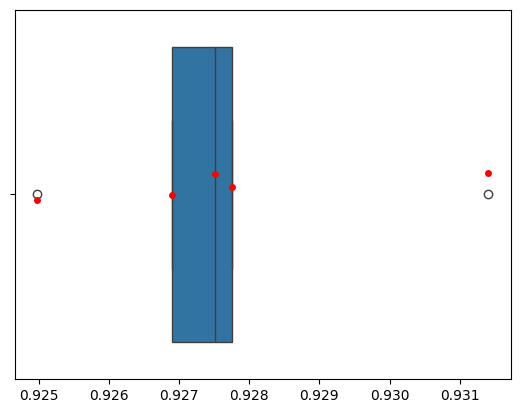

In [ ]:
print('CV R2 Mean :', round(scores_rf.mean(), 3))
print('CV R2 STD :', round(scores_rf.std(), 3))

sns.boxplot(x=scores_rf, orient='h')
sns.stripplot(x=scores_rf, color='red')
plt.show()

In [ ]:
y_train_pred_rf = model_rf.predict(X_train)
y_test_pred_rf = model_rf.predict(X_test)

### R2, RMSE, MAE

In [ ]:
print('Train MAE:', round(mean_absolute_error(y_train, y_train_pred_rf), 3))
print('Train RMSE:', round(np.sqrt(mean_squared_error(y_train, y_train_pred_rf)), 3))
print('Train R2:', round(r2_score(y_train, y_train_pred_rf)* 100, 3), '%')
print('Train MAPE:', round(mean_absolute_percentage_error(y_train, y_train_pred_rf) * 100, 3), '%')

print('Test MAE:', round(mean_absolute_error(y_test, y_test_pred_rf), 3))
print('Test RMSE:', round(np.sqrt(mean_squared_error(y_test, y_test_pred_rf)), 3))
print('Test R2:', round(r2_score(y_test, y_test_pred_rf)* 100, 3), '%')
print('Test MAPE:', round(mean_absolute_percentage_error(y_test, y_test_pred_rf) * 100, 3), '%')

Train MAE: 24.027
Train RMSE: 31.145
Train R2: 98.923 %
Train MAPE: 2.228 %
Test MAE: 61.943
Test RMSE: 79.31
Test R2: 92.551 %
Test MAPE: 5.775 %


### Model Evaluation

/tmp/ipython-input-4195756252.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


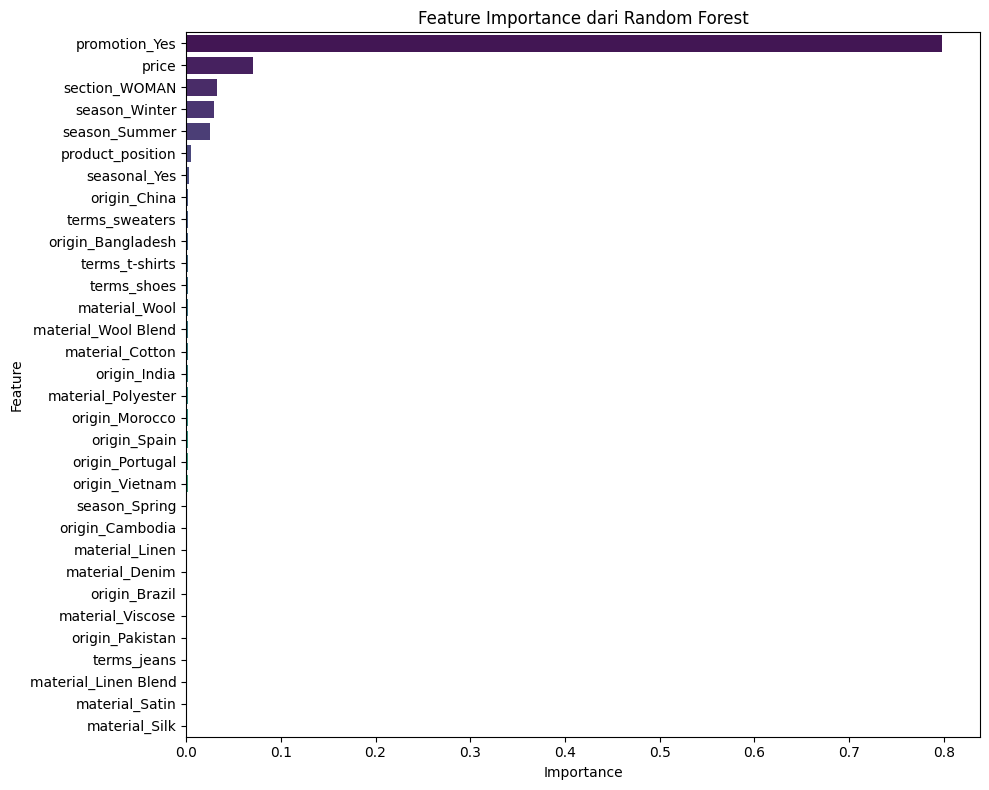

In [ ]:
import pandas as pd

# Feature importance Random Forest
importances = model_rf.feature_importances_

df_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': importances
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10,8))
sns.barplot(
    x='importance',
    y='feature',
    data=df_importance,
    palette='viridis'
)
plt.title('Feature Importance dari Random Forest')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


### Hyperparameter Tuning

In [ ]:
from sklearn.ensemble import RandomForestRegressor

parameters_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf_model = RandomForestRegressor(random_state=42)

rf_grid = RandomizedSearchCV(
    estimator=rf_model,
    param_distributions=parameters_rf,
    n_iter=20,
    cv=5,
    scoring='r2',
    verbose=True,
    n_jobs=-1,
    random_state=42
)

rf_grid.fit(X_train, y_train)

print("Best parameters:", rf_grid.best_params_)
print("Best R2 score (CV):", rf_grid.best_score_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Best parameters: {'n_estimators': 300, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_depth': 7}
Best R2 score (CV): 0.9368642210738883


### Best Parameter

In [ ]:
best_params = rf_grid.best_params_

rf_model_hy = RandomForestRegressor(
    n_estimators=best_params['n_estimators'],
    max_depth=best_params['max_depth'],
    min_samples_split=best_params['min_samples_split'],
    min_samples_leaf=best_params['min_samples_leaf'],
    random_state=42
)

rf_model_hy.fit(X_train, y_train)

scores_rf_hy = cross_val_score(
    rf_model_hy,
    X_train,
    y_train,
    cv=5,
    scoring='r2'
)

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example usi

R2 Mean (CV) : 0.937
R2 STD (CV) : 0.002


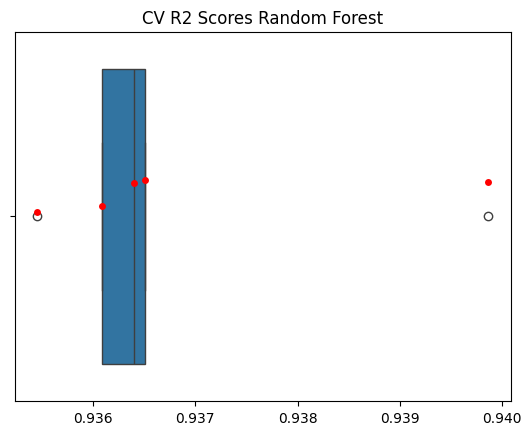

In [ ]:
print('R2 Mean (CV) :', round(scores_rf_hy.mean(), 3))
print('R2 STD (CV) :', round(scores_rf_hy.std(), 3))

sns.boxplot(x=scores_rf_hy, orient='h')
sns.stripplot(x=scores_rf_hy, color='red')
plt.title("CV R2 Scores Random Forest")
plt.show()

In [ ]:
y_train_pred_rf = rf_model_hy.predict(X_train)
y_test_pred_rf = rf_model_hy.predict(X_test)

In [ ]:
print('Train MAE:', round(mean_absolute_error(y_train, y_train_pred_rf), 3))
print('Train RMSE:', round(np.sqrt(mean_squared_error(y_train, y_train_pred_rf)), 3))
print('Train R2:', round(r2_score(y_train, y_train_pred_rf) * 100, 3), '%')
print('Train MAPE:', round(mean_absolute_percentage_error(y_train, y_train_pred_rf) * 100, 3), '%')

print('Test MAE:', round(mean_absolute_error(y_test, y_test_pred_rf), 3))
print('Test RMSE:', round(np.sqrt(mean_squared_error(y_test, y_test_pred_rf)), 3))
print('Test R2:', round(r2_score(y_test, y_test_pred_rf) * 100, 3), '%')
print('Test MAPE:', round(mean_absolute_percentage_error(y_test, y_test_pred_rf) * 100, 3), '%')

Train MAE: 57.532
Train RMSE: 72.963
Train R2: 94.087 %
Train MAPE: 5.317 %
Test MAE: 58.229
Test RMSE: 73.827
Test R2: 93.545 %
Test MAPE: 5.414 %
